#📌 Extracción

Revision de columnas

In [49]:
# -*- coding: utf-8 -*-
"""TelecomX_LATAM"""

import pandas as pd
import matplotlib.pyplot as plt

data_source = "https://raw.githubusercontent.com/ECastro08/challenge_telecomX_2/refs/heads/main/df_telecom.csv"

data = pd.read_csv(data_source)

data.head(3)

# ver columnas
print(data.columns)

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'cuentas_diarias'],
      dtype='object')


In [55]:
# -*- coding: utf-8 -*-
"""TelecomX_LATAM"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# cargar datos desde GitHub
data_source = "https://raw.githubusercontent.com/ECastro08/challenge_telecomX_2/refs/heads/main/df_telecom.csv"

data = pd.read_csv(data_source)

# ver primeras filas
data.head(3)

# revisar columnas
print(data.columns)

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'cuentas_diarias'],
      dtype='object')


Correlación

In [56]:
data[['tenure', 'monthly_charges', 'total_charges']].corr()

,tenure,monthly_charges,total_charges
tenure,1.000000,0.247900,0.826178
monthly_charges,0.247900,1.000000,0.651174
total_charges,0.826178,0.651174,1.000000


Eliminado de variables irrelevantes

In [57]:
data.drop(columns='customer_id', axis=1, inplace=True, errors='ignore')
data.drop(columns='total_charges', axis=1, inplace=True, errors='ignore')
data.drop(columns='cuentas_diarias', axis=1, inplace=True, errors='ignore')

🔧 Transformación

In [58]:
# Separación de variables
X = data.drop("churn", axis=1)
y = data["churn"]

# dividir los datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#📊 Carga y análisis

In [59]:
round(y.value_counts(normalize=True),4)*100

,proportion
churn,
0,73.46
1,26.54


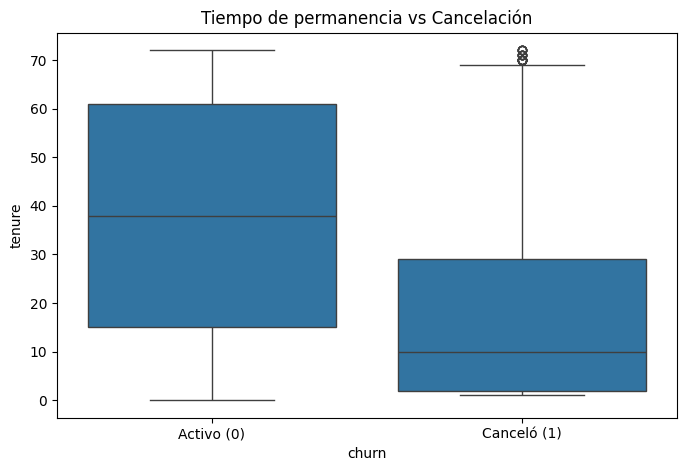

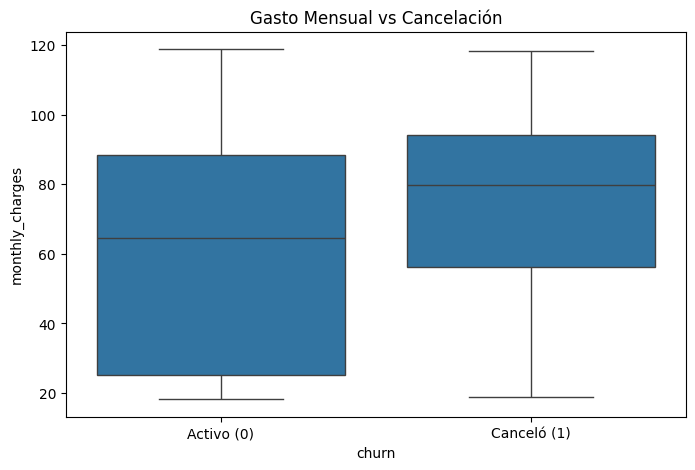

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure', data=data)
plt.title("Tiempo de permanencia vs Cancelación")
plt.xticks([0,1], ['Activo (0)', 'Canceló (1)'])
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='monthly_charges', data=data)
plt.title("Gasto Mensual vs Cancelación")
plt.xticks([0,1], ['Activo (0)', 'Canceló (1)'])
plt.show()

Modelado

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# columnas categóricas y numéricas
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# transformadores
categorical_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)

numeric_transformer = StandardScaler()

# preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

Modelos

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision tree": DecisionTreeClassifier(random_state=42),
    "Decision tree balanced": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

Entrenamiento y evaluacion

In [63]:
results = []

for name, classifier in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

comparacion de modelos

In [70]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Recall (Churn),F1-score,ROC-AUC
4,Gradient Boosting,0.794180,0.505348,0.565868,0.845403
0,Logistic Regression,0.794890,0.526738,0.576867,0.841680
3,Random Forest,0.788502,0.483957,0.548485,0.816915
1,Decision tree,0.716111,0.491979,0.479167,0.644868
2,Decision tree balanced,0.721079,0.459893,0.466757,0.638981


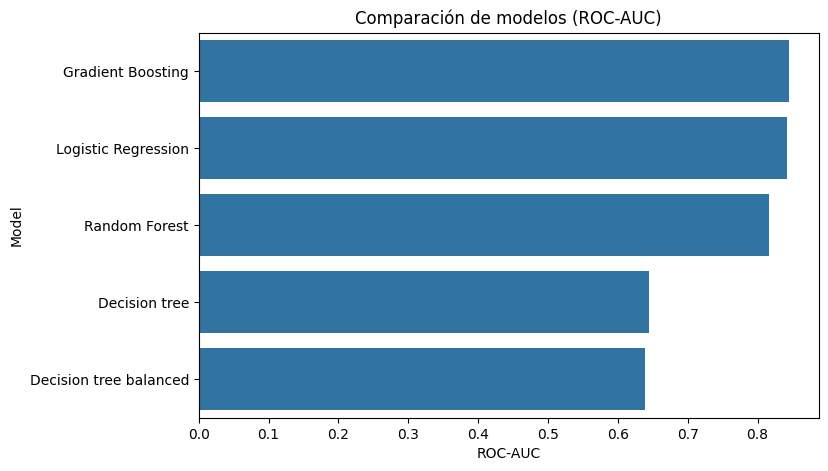

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model")

plt.title("Comparación de modelos (ROC-AUC)")
plt.show()

#📄Informe final

El objetivo de este proyecto fue analizar los factores asociados a la cancelacion de clientes (churn)
en la empresa TelecomX y construir modelos de machine learning capaces de predecir que clientes tienen mayor probabilidad de abandonar el servicio.
Este tipo de analisis permite a la empresa anticiparse a la perdida de clientes y diseñar estrategias de retencion mas efectivas.

Tras entrenar y evaluar los modelos, se compararon sus resultados mediante la metrica ROC-AUC, que mide la capacidad del model para distinguir entre clientes que cancelaron y los que permanecen.

A partir  del análisis realizado se identificaron varios factores relaqcionados con la cancelacion de clientes:

Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar.
Los cargos mensuales elevados estan asociados con mayor churn.
Algunas caracteristicas del servicio tambien influyen en la decision de permanecer o cancelar.  